# README
1. AUSPEX is a BBN instrumnet control package. 
2. We are using SRS SR865 lockin + RenSci piezo stage. Both connected via ethernet with static IP addresses
3. AUSPEX has a number of 'import visa' scattered across the source code; needs to be updated to 'import pyvisa as visa'. Best to push these changes or fork the repo and have a local copy.
4. distance unit is in millimeter.

In [1]:
%load_ext autoreload
%autoreload 2
from auspex.instruments import SR865
from rensci import RenSciDriver
import numpy as np
import time

auspex-WARNING: 2026-06-02 18:41:25,141 ----> You may not have the libusb backend: please install it!


In [2]:
PIEZO_HOST = "172.31.255.99"
PIEZO_PORT = 6002

In [3]:
lockin = SR865()
lockin.connect('TCPIP0::172.31.255.252')

print(f"Connected to {lockin.name} \n\n X= {lockin.x}, Y = {lockin.y}")

xyz = RenSciDriver(PIEZO_HOST, PIEZO_PORT)
xyz.connect()

Connected to SR865 Lockin Amplifier 

 X= 0.0047014490701, Y = -0.00025340748834
Connected to 172.31.255.99:6002


In [10]:
xyz.goPosition(1, -4.4)
xyz.goPosition(2, -1.15)
xyz.goPosition(3, -3.23)
r=[]
# for i in range(100):
#     xyz.goStepsForward(1, steps=10)
#     r.append(lockin.r)

In [4]:
import matplotlib.pyplot as plt

In [6]:
xyz.goPosition(1, -4)


{'id': '178', 'jsonrpc': '2.0', 'result': True}

In [7]:
r=[]
x = []
for i in range(600):
    xyz.goStepsForward(1, steps=10)
    r.append(lockin.r)
    x.append(xyz.getPosition(1))

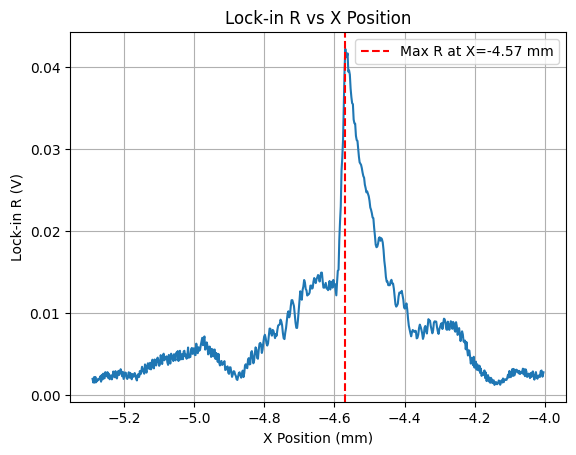

In [18]:
r = np.array(r)
x = np.array(x)
np.argmax(r)

plt.plot(x, r)
plt.xlabel("X Position (mm)")
plt.ylabel("Lock-in R (V)")
plt.title("Lock-in R vs X Position")
plt.axvline(x[np.argmax(r)], color='r', linestyle='--', label=f'Max R at X={x[np.argmax(r)]:.2f} mm')
plt.grid()
plt.legend()

In [19]:
xyz.goPosition(1, x[np.argmax(r)]  )

{'id': '24921', 'jsonrpc': '2.0', 'result': True}

In [28]:
xyz.goPosition(2, -1.15 )
nsteps = 2000
stepsize = 10
y = []
r= []
xyz.goStepsReverse(2, int(nsteps/2))
for i in range(nsteps):
    r.append(lockin.r)
    y.append(xyz.getPosition(2))
    xyz.goStepsForward(2, stepsize)

In [16]:
r[263]

np.float64(0.042213559151)

/var/folders/62/mcqwstd50y96l1tfpcvcwz6w0000gn/T/ipykernel_32257/2211636307.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


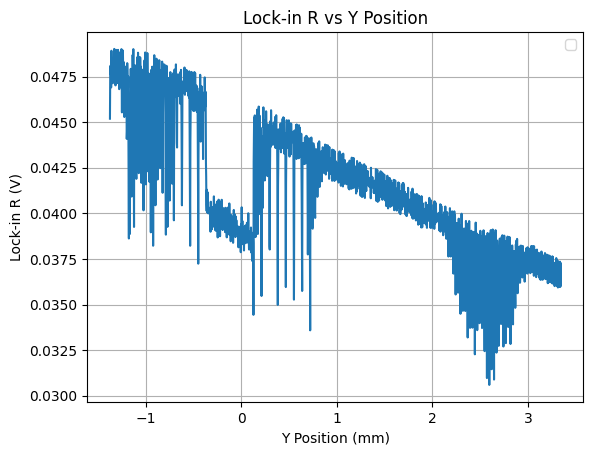

In [29]:
r = np.array(r)
y = np.array(y)
# np.argmax(r)

plt.plot(y, r)
plt.xlabel("Y Position (mm)")
plt.ylabel("Lock-in R (V)")
plt.title("Lock-in R vs Y Position")
# plt.axvline(y[np.argmax(r)], color='r', linestyle='--', label=f'Max R at Y={y   [np.argmax(r)]:.2f} mm')
plt.grid()
plt.legend()

In [27]:
np.mean(np.diff(y))*1e3

np.float64(4.828772024525778)

In [5]:
def refocus(channel=1, nsteps=15, stepsize=10, lockin_time_constant=0.03):
    x=[]
    r=[]
    xyz.goStepsReverse(channel, int(nsteps/2)*stepsize)
    for i in range(nsteps):
        time.sleep(lockin_time_constant * 5)  # Wait for lock-in to stabilize
        r.append(lockin.r)
        x.append(xyz.getPosition(channel))
        xyz.goStepsForward(channel, stepsize)
    r = np.array(r)
    x = np.array(x)
    return x[np.argmax(r)], x,r
    
def getStepDistance(channel=2, stepSize=10, nsteps=10):
    step = []
    distance = []

    # Record the starting position
    startPosition = xyz.getPosition(channel)

    for i in range(nsteps):
        xyz.goStepsForward(channel, stepSize)
        step.append((i + 1) * stepSize)
        distance.append(xyz.getPosition(channel) - startPosition)

    # Linear fit: distance = slope * step + intercept
    coeffs = np.polyfit(step, distance, 1)
    slope = coeffs[0]  # microns per step unit

    # Distance per single step (stepSize=1)
    distancePerStep = slope  # mm/step
    xyz.goPosition(channel, startPosition)  # Return to original position
    return distancePerStep


# xyz.goPosition(1, refocus(channel=1)[0])


In [ ]:
#test getStepDistance
xyz.goPosition(2, -1.15 )
distancePerStep = getStepDistance(channel=2, stepSize=10, nsteps=10)
print(f"Distance per step unit: {distancePerStep:.4f} mm/step")


Distance per step unit: 0.2533 microns/step


In [35]:
xyz.goPosition(2, -1.15)

{'id': '463', 'jsonrpc': '2.0', 'result': True}

In [39]:
print({k: v for k, v in vars(type(lockin)).items() if 'filter' in k.lower()})

{'FILTER_SLOPE_VALUES': [6, 12, 18, 24], 'FILTER_SLOPE_MAP': {6: '0', 12: '1', 18: '2', 24: '3'}, 'filter_slope': <property object at 0x11e64f3d0>, 'get_filter_slope': <function add_command_SCPI.<locals>.fget at 0x11e69f7e0>, 'set_filter_slope': <function add_command_SCPI.<locals>.fset at 0x11e69f880>}


In [63]:
xyz.goPosition(2, -1.15)
xyz.goPosition(1, 4.4)
xyz.goPosition(3, -3.23)


{'id': '159183', 'jsonrpc': '2.0', 'result': True}

>> Initializing position...
   Starting position: X=4.5650, Y=-1.1500, Z=-3.2300 mm

>> Calibrating step distance...
   Resolution (mm/step): 0.0014
   Total steps: 55


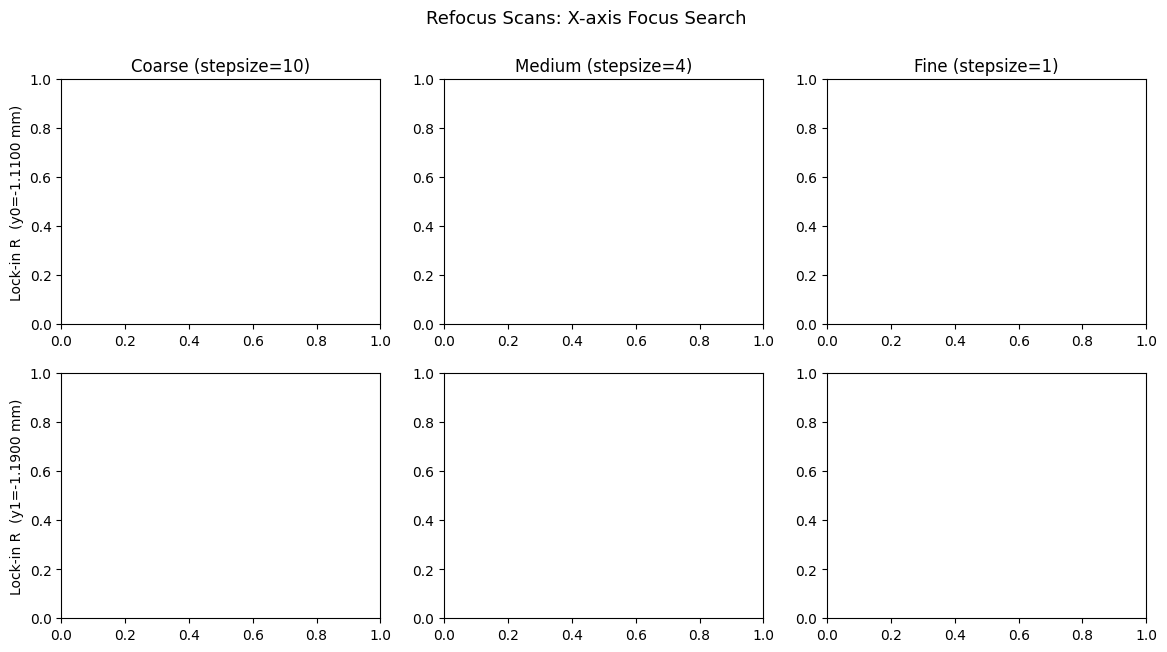


>> Finding focus at y0=-1.1100 mm...
   Coarse refocus (stepsize=10)...
   Medium refocus (stepsize=4)...
   Fine refocus (stepsize=1)...
   x0 = 4.5641 mm

>> Finding focus at y1=-1.1900 mm...
   Coarse refocus (stepsize=10)...
   Medium refocus (stepsize=4)...
   Fine refocus (stepsize=1)...
   x1 = 4.5423 mm

>> Defocus slope computed:
   Focus X at y0=-1.110: 4.5641 mm
   Focus X at y1=-1.190: 4.5423 mm
   Defocus slope: 0.2723 mm/mm

========== SCAN PARAMETERS ==========
  Lock-in frequency  : 177.77 Hz
  Time constant      : 30.0 ms
  Sensitivity        : 10.0 mV
  Filter slope       : 6 dB/oct
  Start position     : X=4.5650, Y=-1.1500, Z=-3.2300 mm
  Scan axis          : Y  (-1.1100 → -1.1900 mm)
  Scan size          : 0.080 mm
  Step size          : 5 | Step distance: 0.0003 mm | Total steps: 55
  Resolution         : 0.0014 mm/step


>> Returning to scan start...

>> Calibrating step distance...

>> Starting line scan (322 steps)...
   Scan progress: 0%  (step 1/322, Y=-1.11

KeyboardInterrupt: 

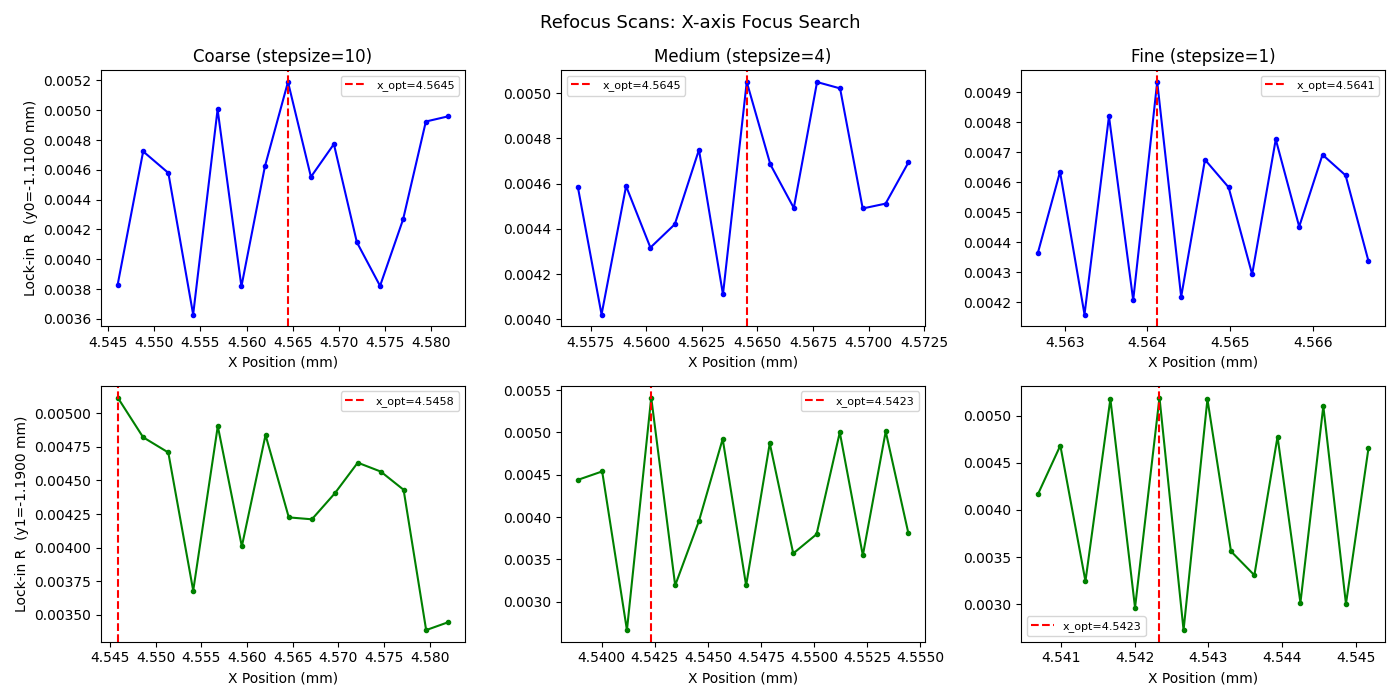

In [8]:
#  LZ - 06/02/2026
# Refocus line estimate and test line scan (claude version)

#lock-in setting
lockin.amplitude = 0.02
lockin.frequency = 1.7777*1e2
lockin.time_constant = 0.03
lockin.sensitivity = 10*1e-3
lockin.phase = 0
lockin.filter_slope = 6

# Parameters (defined first)
stepsize = 5          # scanning resolution; smaller = higher res, slower
scanYSize = 0.08      # total scan size in Y (mm)

# Initialize position
print(">> Initializing position...")
xyz.goPosition(2, -1.15)
xyz.goPosition(1, 4.565)
xyz.goPosition(3, -3.23)
currentXPosition = xyz.getPosition(1)
currentYPosition = xyz.getPosition(2)
currentZPosition = xyz.getPosition(3)
print(f"   Starting position: X={currentXPosition:.4f}, Y={currentYPosition:.4f}, Z={currentZPosition:.4f} mm")

# Calibrate step distance and compute number of steps
print("\n>> Calibrating step distance...")
yOneStepDistance = getStepDistance(channel=2, stepSize=stepsize, nsteps=10)
nsteps = int(round(scanYSize / (yOneStepDistance*stepsize)))
print(f"   Resolution (mm/step): {yOneStepDistance * stepsize:.4f}")
print(f"   Total steps: {nsteps}")

# Scan range endpoints
y0 = currentYPosition + scanYSize / 2
y1 = currentYPosition - scanYSize / 2

%matplotlib widget

# Setup refocus figure
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fig.suptitle('Refocus Scans: X-axis Focus Search', fontsize=13)
for col, title in enumerate(['Coarse (stepsize=10)', 'Medium (stepsize=4)', 'Fine (stepsize=1)']):
    axes[0, col].set_title(title)
axes[0, 0].set_ylabel(f'Lock-in R  (y0={y0:.4f} mm)')
axes[1, 0].set_ylabel(f'Lock-in R  (y1={y1:.4f} mm)')
display(fig)  # show the empty figure first

# ── Find focus at y0 ──────────────────────────────────────
print(f"\n>> Finding focus at y0={y0:.4f} mm...")
xyz.goPosition(2, y0)

for col, ss in enumerate([10, 4, 1]):
    label = ['Coarse', 'Medium', 'Fine'][col]
    print(f"   {label} refocus (stepsize={ss})...")
    x_opt, x_scan, r_scan = refocus(channel=1, nsteps=15, stepsize=ss,
                                     lockin_time_constant=lockin.time_constant)
    xyz.goPosition(1, x_opt)
    x0 = x_opt

    ax = axes[0, col]
    ax.plot(x_scan, r_scan, 'b.-')
    ax.axvline(x_opt, color='r', linestyle='--', label=f'x_opt={x_opt:.4f}')
    ax.legend(fontsize=8)
    ax.set_xlabel('X Position (mm)')
    fig.canvas.draw()  # update figure in real time
    fig.canvas.flush_events()

print(f"   x0 = {x0:.4f} mm")

# ── Find focus at y1 ──────────────────────────────────────
print(f"\n>> Finding focus at y1={y1:.4f} mm...")
xyz.goPosition(2, y1)

for col, ss in enumerate([10, 4, 1]):
    label = ['Coarse', 'Medium', 'Fine'][col]
    print(f"   {label} refocus (stepsize={ss})...")
    x_opt, x_scan, r_scan = refocus(channel=1, nsteps=15, stepsize=ss,
                                     lockin_time_constant=lockin.time_constant)
    xyz.goPosition(1, x_opt)
    x1 = x_opt

    ax = axes[1, col]
    ax.plot(x_scan, r_scan, 'g.-')
    ax.axvline(x_opt, color='r', linestyle='--', label=f'x_opt={x_opt:.4f}')
    ax.legend(fontsize=8)
    ax.set_xlabel('X Position (mm)')
    fig.canvas.draw()  # update figure in real time
    fig.canvas.flush_events()

print(f"   x1 = {x1:.4f} mm")
fig.tight_layout()

# Compute defocus slope
defocusSlope = (x1 - x0) / (y1 - y0)
print(f"\n>> Defocus slope computed:")
print(f"   Focus X at y0={y0:.3f}: {x0:.4f} mm")
print(f"   Focus X at y1={y1:.3f}: {x1:.4f} mm")
print(f"   Defocus slope: {defocusSlope:.4f} mm/mm")

# ── Scan summary ──────────────────────────────────────────
print("\n========== SCAN PARAMETERS ==========")
print(f"  Lock-in frequency  : {lockin.frequency:.2f} Hz")
print(f"  Time constant      : {lockin.time_constant*1e3:.1f} ms")
print(f"  Sensitivity        : {lockin.sensitivity*1e3:.1f} mV")
print(f"  Filter slope       : {lockin.filter_slope} dB/oct")
print(f"  Start position     : X={currentXPosition:.4f}, Y={currentYPosition:.4f}, Z={currentZPosition:.4f} mm")
print(f"  Scan axis          : Y  ({y0:.4f} → {y1:.4f} mm)")
print(f"  Scan size          : {scanYSize:.3f} mm")
print(f"  Step size          : {stepsize} | Step distance: {yOneStepDistance:.4f} mm | Total steps: {nsteps}")
print(f"  Resolution         : {yOneStepDistance * stepsize:.4f} mm/step")
print("=====================================\n")

# Return to start of scan
print("\n>> Returning to scan start...")
xyz.goPosition(2, y0)
xyz.goPosition(1, x0)

# Calibrate step distance and compute number of steps
print("\n>> Calibrating step distance...")
yOneStepDistance = getStepDistance(channel=2, stepSize=stepsize, nsteps=10)
nsteps = int(round(scanYSize / yOneStepDistance))

# Line scan with live focus correction
print(f"\n>> Starting line scan ({nsteps} steps)...")
yPosition = []
r = []
last_reported = -1

for i in range(nsteps):
    xyz.goStepsReverse(2, stepsize)
    currentY = xyz.getPosition(2)
    yPosition.append(currentY)
    xyz.goPosition(1, x0 + defocusSlope * (currentY - y0))
    time.sleep(lockin.time_constant * 5)  # Wait for lock-in to stabilize
    r.append(lockin.r)

    pct = int((i + 1) / nsteps * 100)
    milestone = (pct // 5) * 5
    if milestone > last_reported:
        print(f"   Scan progress: {milestone}%  (step {i+1}/{nsteps}, Y={currentY:.4f} mm)")
        last_reported = milestone

print(">> Scan complete.")

# Plot
plt.plot(yPosition, r)
plt.xlabel('Y Position (mm)')
plt.ylabel('Lock-in Signal (V)')
plt.title('Lock-in Signal vs Y Position')
plt.show()

In [9]:
# Plot
plt.plot(yPosition, r)
plt.xlabel('Y Position (mm)')
plt.ylabel('Lock-in Signal (V)')
plt.title('Lock-in Signal vs Y Position')
plt.show()

ValueError: x and y must have same first dimension, but have shapes (90,) and (89,)

In [ ]:
#  LZ - 06/02/2026
#  before claude edits
#  Refocus line estimate and test line scan

#lock-in setting
lockin.frequency = 1.7777e3
lockin.time_constant = 3e-3
lockin.sensitivity = 10*1e-3
lockin.phase = 0
lockin.filter_slope = 6

# Parameters (defined first)
stepsize = 2          # scanning resolution; smaller = higher res, slower
scanYSize = 0.05       # in mm

# Initialize position
xyz.goPosition(2, -1.15)
xyz.goPosition(1, 4.4)
xyz.goPosition(3, -3.23)
currentXPosition = xyz.getPosition(1)
currentYPosition = xyz.getPosition(2)
currentZPosition = xyz.getPosition(3)

# Calibrate step distance and compute number of steps
yOneStepDistance = getStepDistance(channel=2, stepSize=stepsize, nsteps=10)
nsteps = int(round(scanYSize / (yOneStepDistance * stepsize)))
print(f"Resolution (mm/step): {yOneStepDistance * stepsize:.4f}")
print(f"Total steps: {nsteps}")

# Scan range endpoints
y0 = currentYPosition + scanYSize / 2
y1 = currentYPosition - scanYSize / 2

# Find focus at y0
xyz.goPosition(2, y0)
xyz.goPosition(1, refocus(channel=1, nsteps=15, stepsize=10)[0])
xyz.goPosition(1, refocus(channel=1, nsteps=15, stepsize=4)[0])
x0 = refocus(channel=1, nsteps=15, stepsize=1)[0]
xyz.goPosition(1, x0)

# Find focus at y1
xyz.goPosition(2, y1)
xyz.goPosition(1, refocus(channel=1, nsteps=15, stepsize=10)[0])
xyz.goPosition(1, refocus(channel=1, nsteps=15, stepsize=4)[0])
x1 = refocus(channel=1, nsteps=15, stepsize=1)[0]
xyz.goPosition(1, x1)

# Compute defocus slope
defocusSlope = (x1 - x0) / (y1 - y0)
print(f"Focus X at y0={y0:.3f}: {x0:.4f} mm")
print(f"Focus X at y1={y1:.3f}: {x1:.4f} mm")
print(f"Defocus slope: {defocusSlope:.4f} mm/mm")

# Return to start of scan
xyz.goPosition(2, y0)
xyz.goPosition(1, x0)

# Line scan with live focus correction
yPosition = []
r = []

for i in range(nsteps):
    xyz.goStepsReverse(2, stepsize)
    currentY = xyz.getPosition(2)
    yPosition.append(currentY)
    xyz.goPosition(1, x0 + defocusSlope * (currentY - y0))
    r.append(lockin.r)

# Plot
plt.plot(yPosition, r)
plt.xlabel('Y Position (mm)')
plt.ylabel('Lock-in Signal (V)')
plt.title('Lock-in Signal vs Y Position')
plt.show()

Resolution (mm/step): 0.0012
Total steps: 1663
Focus X at y0=-0.900: 4.4160 mm
Focus X at y1=-1.400: 4.4212 mm
Defocus slope: -0.0106 mm/mm


KeyboardInterrupt: 

In [ ]:

x0, x, r = refocus(1)

NameError: name 'refocus' is not defined

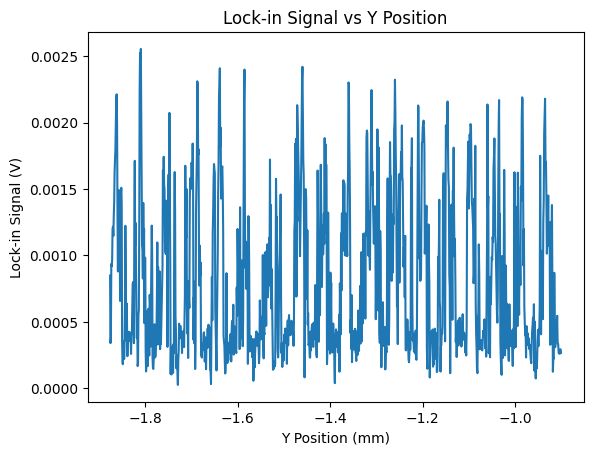

In [53]:
# Plot
plt.plot(yPosition, r)
plt.xlabel('Y Position (mm)')
plt.ylabel('Lock-in Signal (V)')
plt.title('Lock-in Signal vs Y Position')
plt.show()

In [68]:
xyz.goPosition(1, x0)

{'id': '228266', 'jsonrpc': '2.0', 'result': True}

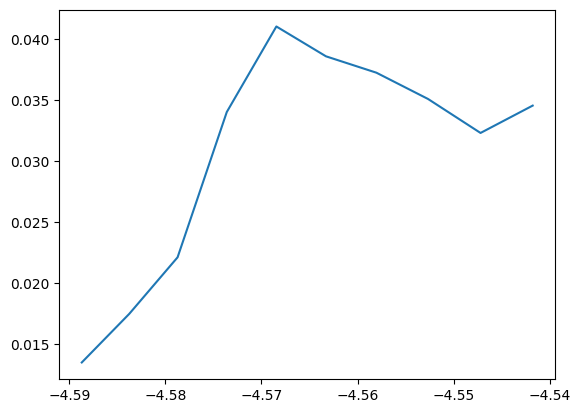

In [72]:
plt.plot(x,r)

In [57]:
xyz.goPosition(1, x0)

{'id': '226381', 'jsonrpc': '2.0', 'result': True}

In [41]:
np.mean(np.diff(refocus(channel=1)[1]))

np.float64(-0.009523392657737209)

In [74]:
xyz.goPosition(2, -1.15 )
nsteps = 200
stepsize = 20
y = []
r= []
x0=[]
xyz.goStepsReverse(2, int(nsteps/2)*stepsize)
for i in range(nsteps):
    r.append(lockin.r)
    y.append(xyz.getPosition(2))
    xyz.goStepsForward(2, stepsize)
    
    x0.append( refocus(channel=1)[0] )
    xyz.goPosition(1, x0[-1])



KeyboardInterrupt: 

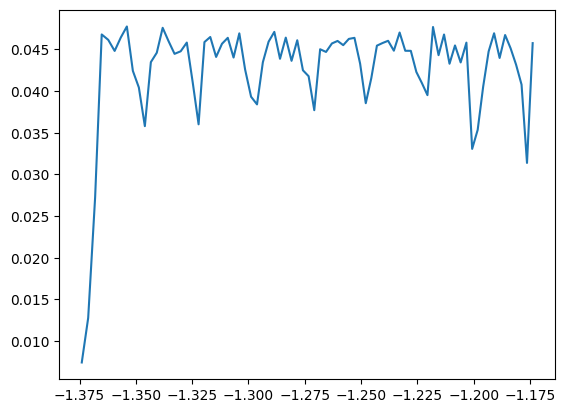

In [43]:
plt.plot(y, r)

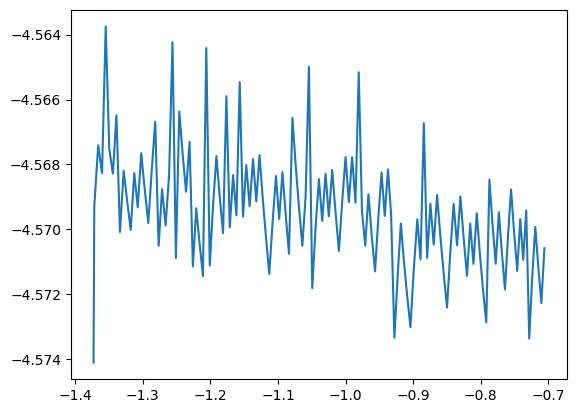

In [80]:
plt.plot(y[:-1],x0)

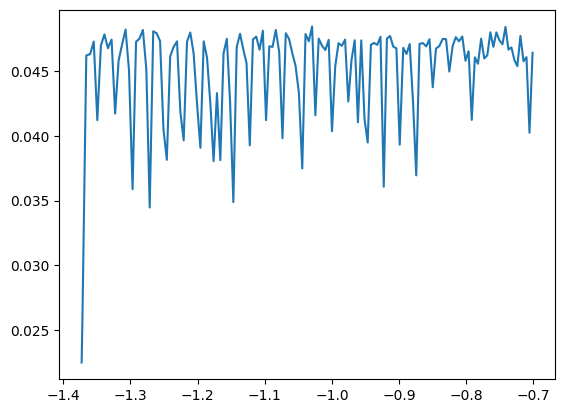

In [81]:
plt.plot(y, r)

In [83]:
np.mean(np.diff(y))*1e3

np.float64(4.86577745693015)